# Week 1 ECG Visualization

# This notebook will contain:

1-Load ECG data from MIT-BIH dataset

2-Inspect the signal

3-Plot the ECG waveform

4-Show heartbeat annotations

# The 3 Important File Types

Every record has 3 files.

1.dat file

This file contains the actual ECG signal numbers.

2️.hea file (Header)

This file contains metadata about the recording.
Example:

100 2 360 650000
| Value  | Meaning            |
| ------ | ------------------ |
| 100    | record number      |
| 2      | number of leads    |
| 360    | samples per second |
| 650000 | total samples      |

3.atr file (Annotations)

This file contains labels for heartbeats.

Doctors manually annotated these beats.
```
Example conceptually:
sample_index   beat_type
77             N
370            N
662            V
946            N
```

| Symbol | Meaning          |
| ------ | ---------------- |
| N      | Normal beat      |
| V      | Ventricular beat |
| A      | Atrial beat      |
| L      | Left bundle beat |

These annotations are very important because they are the ground truth labels for ML.



In [7]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
DATA_PATH = "../dataset/mitdb/"
RECORD_NAME = "100"

In [9]:
record = wfdb.rdrecord(DATA_PATH + RECORD_NAME)
annotation = wfdb.rdann(DATA_PATH + RECORD_NAME, "atr")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)

Signal shape: (650000, 2)
Sampling frequency: 360


650000 samples ÷ 360 samples/sec
≈ 1805 seconds
≈ 30 minutes

| Term           | Meaning                          |
| -------------- | -------------------------------- |
| 650000 samples | total ECG measurements           |
| 2 leads        | two different heart signal views |
| 360 Hz         | 360 measurements per second      |
| 30 minutes     | total recording length           |


In [32]:
#Inspect Signal Data
record.p_signal[:1000]


array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       ...,
       [-0.385, -0.26 ],
       [-0.375, -0.26 ],
       [-0.385, -0.275]])

Each row = ECG voltage reading

Plot First 1000 Samples

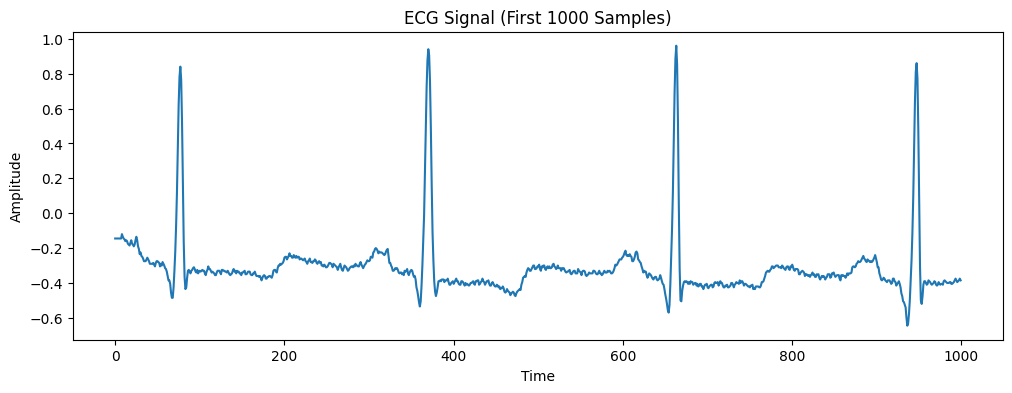

In [11]:
plt.figure(figsize=(12,4))

plt.plot(record.p_signal[:1000,0])

plt.title("ECG Signal (First 1000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

Plot Longer ECG Segment

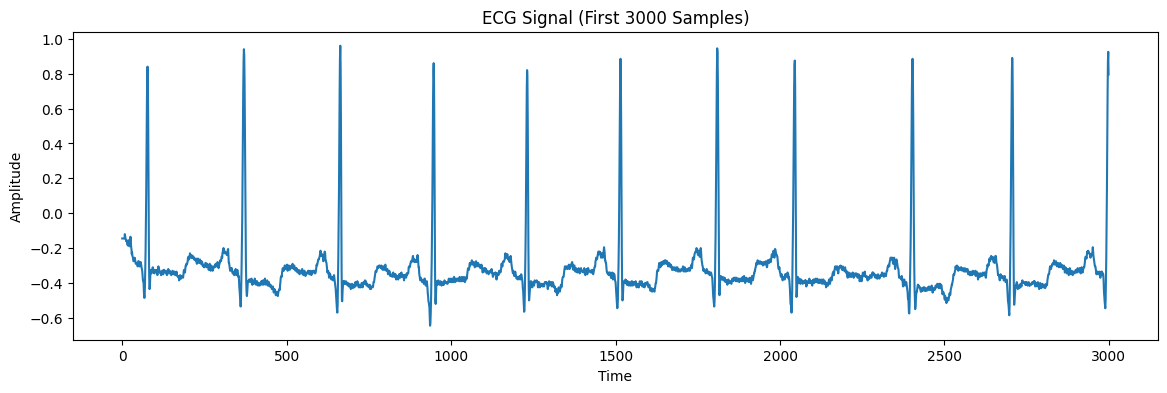

In [12]:
plt.figure(figsize=(14,4))

plt.plot(record.p_signal[:3000,0])
# means:
# Take first 3000 samples
# from lead 0
#3000 / 360 ≈ 8.33 seconds
plt.title("ECG Signal (First 3000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

View Annotation Information

Annotations tell us what type of heartbeat occurred.

In [13]:
print("First 10 annotation samples:")
print(annotation.sample[:10])

print("First 10 annotation symbols:")
print(annotation.symbol[:10])

First 10 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


| Sample | Time     |
| ------ | -------- |
| 77     | 0.21 sec |
| 370    | 1.02 sec |
| 662    | 1.84 sec |
| 946    | 2.63 sec |

So the heartbeats occurred at those time points.

Plot ECG with Beat Markers

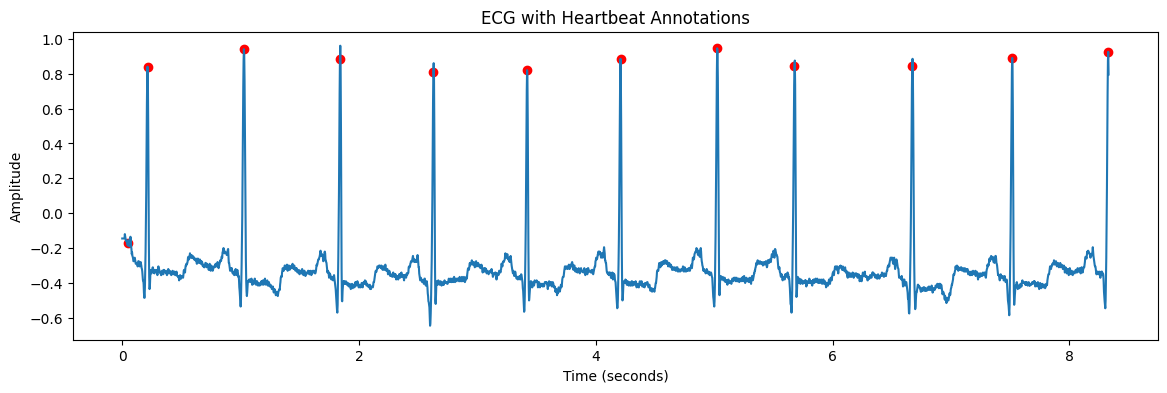

In [14]:
plt.figure(figsize=(14,4))

signal = record.p_signal[:3000,0]

# convert samples to time
time = np.arange(len(signal)) / record.fs

plt.plot(time, signal)

beat_positions = annotation.sample
beat_positions = beat_positions[beat_positions < 3000]

plt.scatter(beat_positions/record.fs, signal[beat_positions], color='red')

plt.title("ECG with Heartbeat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

Basic Statistics

In [15]:
print("Min value:", np.min(record.p_signal))
print("Max value:", np.max(record.p_signal))
print("Mean value:", np.mean(record.p_signal))

Min value: -2.715
Max value: 1.435
Mean value: -0.24866670384615372


Why This Is Useful

These statistics help us to understand:

Signal range

Noise level

Scaling needed for ML


# 🔍 Week 2 — Data Exploration (EDA)

📂 2. Load ECG Dataset

Most ECG datasets (like MIT-BIH) use WFDB format

In [31]:
import wfdb

record = wfdb.rdrecord('../dataset/mitdb/100')
annotation = wfdb.rdann('../dataset/mitdb/100', 'atr')

signal = record.p_signal[:, 0]
samples = annotation.sample
labels = annotation.symbol

# 🔍 ADD DEBUG HERE 👇
print("Signal length:", len(signal))
print("Total samples:", len(samples))
print("Unique labels:", set(labels))

Signal length: 650000
Total samples: 2274
Unique labels: {'N', 'V', 'A', '+'}


| Thing     | Meaning                                 |
| --------- | --------------------------------------- |
| `signal`  | All recorded points (every tiny moment) |
| `samples` | Only heartbeat locations                |


In [27]:
signal

array([-0.145, -0.145, -0.145, ..., -0.675, -0.765, -1.28 ])

What we got:

signal → ECG waveform

samples → where beats occur

labels → type of beat


3. Plot ECG Signal


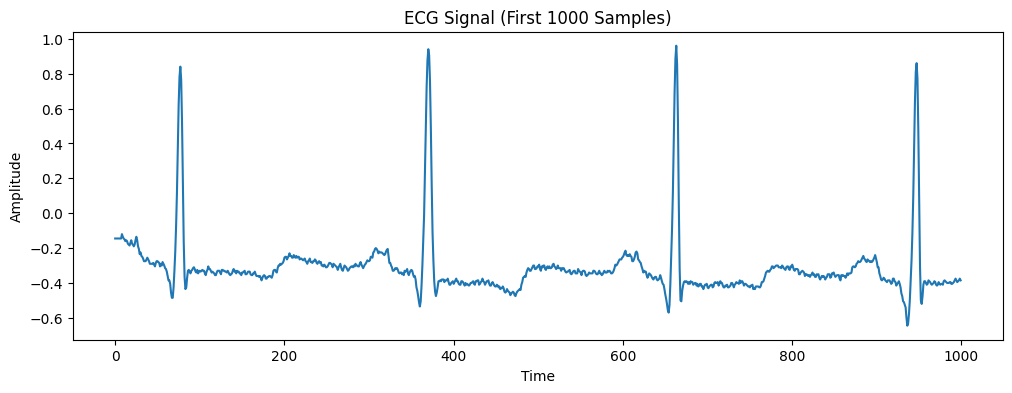

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(signal[:1000])
plt.title("ECG Signal (First 1000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

🧠 What to observe:

Repeating peaks = normal rhythm

Irregular pattern = arrhythmia

# 5. Extract Individual Heartbeats

  ML model doesn’t learn full signal

  It learns small heartbeat segments

In [20]:
beats = []
beat_labels = []

window = 100

for i in range(len(samples)):
    s = samples[i]
    
    if s - window > 0 and s + window < len(signal):
        beats.append(signal[s-window:s+window])
        beat_labels.append(labels[i])

 Now you have:

beats → list of heartbeat signals

beat_labels → corresponding labels

6. Plot Individual Heartbeats

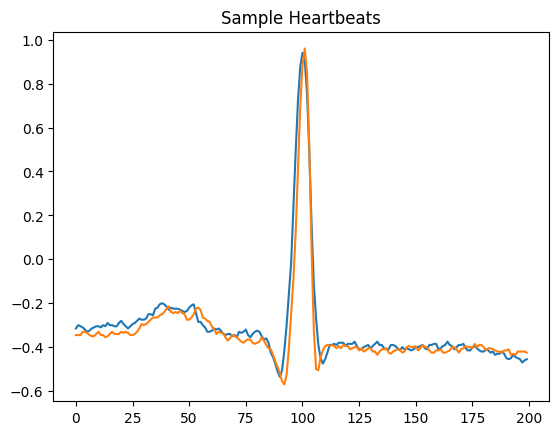

In [21]:
for i in range(2):
    plt.plot(beats[i])
plt.title("Sample Heartbeats")
plt.show()

7. Dataset Statistics

In [23]:
print("Total signal length:", len(signal))

Total signal length: 650000


In [25]:
print("Total beats:", len(beats))

Total beats: 2271


In [ ]:
from collections import Counter
print(Counter(beat_labels))

Counter({'N': 2237, 'A': 33, 'V': 1})


Plot distribution

In [ ]:
from collections import Counter

count = Counter(beat_labels)

print("Count:", count)
print("Keys:", list(count.keys()))
print("Values:", list(count.values()))

Count: Counter({'N': 2237, 'A': 33, 'V': 1})
Keys: ['N', 'A', 'V']
Values: [2237, 33, 1]


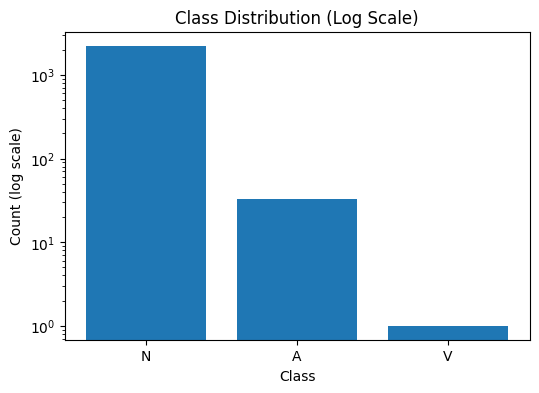

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(count.keys(), count.values())

plt.yscale('log')  # 🔥 IMPORTANT
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.show()

| Observation     | Meaning           |
| --------------- | ----------------- |
| Huge N          | Normal dominates  |
| Very few V      | Rare but critical |
| Imbalanced data | ML challenge      |


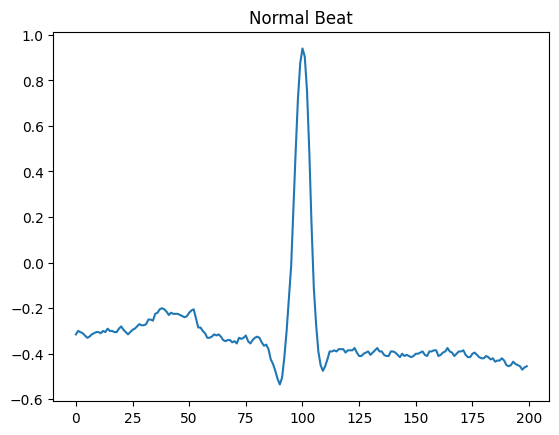

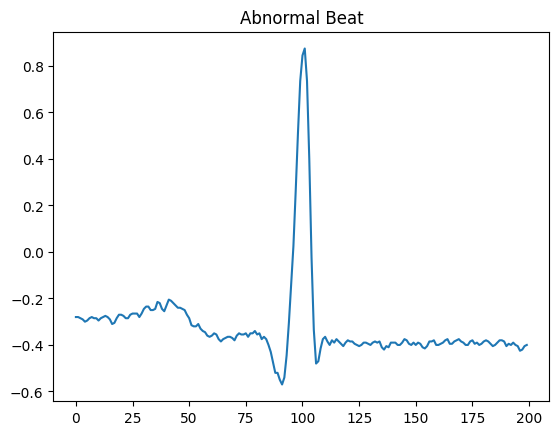

In [ ]:
for i in range(len(beats)):
    if beat_labels[i] == 'N':
        plt.plot(beats[i])
        break

plt.title("Normal Beat")
plt.show()

for i in range(len(beats)):
    if beat_labels[i] != 'N':
        plt.plot(beats[i])
        break

plt.title("Abnormal Beat")
plt.show()

# Week 3 — Data Preprocessing

Step 1: Why Preprocessing is Needed?

Raw ECG is:

Noisy ⚠️ (machine noise, body movement)
Different scales ⚠️
Continuous signal ⚠️ (ML needs fixed-size input)

So we do:

👉 Clean → Normalize → Segment → Label

1. Noise Removal (Filtering)

 What is noise?

ECG gets disturbed by:

Muscle movement

Powerline noise (50/60 Hz)

Baseline drift

✅ Solution: Filtering

We use:

Bandpass filter (0.5 Hz – 40 Hz)

👉 0.5–40 Hz is used because it keeps all important heart information and removes noise.

Filtering ECG

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

Explanation

butter() → creates filter

filtfilt() → applies filter (no phase distortion)

fs=360 → sampling rate (MIT-BIH dataset)

# 2. Normalization

🔍 Problem

Different signals have different ranges:

ML gets confused 😵

Signal A: -2 to 2

Signal B: -0.5 to 0.5

✅ Solution: Normalize

Convert all signals to same scale:

In [ ]:
import numpy as np

def normalize(signal):
    return (signal - np.mean(signal)) / np.std(signal)

💡 Explanation

Mean = 0

Std = 1

👉 Standardization → best for ML models

# 3. Beat Segmentation (MOST IMPORTANT)

🔥 Idea:

Instead of full ECG:

👉 Take small window around each heartbeat

For each R-peak (annotation):

Take:

100 samples before

100 samples after

Total = 200-length vector

In [ ]:
def segment_beats(signal, annotations, window_size=100):
    beats = []
    labels = []

    for i, r_peak in enumerate(annotations.sample):
        if r_peak - window_size > 0 and r_peak + window_size < len(signal):
            beat = signal[r_peak - window_size : r_peak + window_size]
            beats.append(beat)
            labels.append(annotations.symbol[i])

    return beats, labels

In [ ]:
filtered = bandpass_filter(signal)
normalized = normalize(filtered)
X, y = segment_beats(normalized, annotation)

In [ ]:
X

[array([-3.79018914e-02, -3.83789475e-02, -4.18075879e-02, -4.87584326e-02,
        -5.70218869e-02, -6.23576272e-02, -6.05851409e-02, -4.97438861e-02,
        -3.10894303e-02, -8.47861114e-03,  1.33799319e-02,  3.08449973e-02,
         4.25718980e-02,  4.96514982e-02,  5.47359627e-02,  6.05507813e-02,
         6.83812825e-02,  7.72060947e-02,  8.40286862e-02,  8.54904055e-02,
         8.01118315e-02,  6.99265722e-02,  6.03665539e-02,  5.81677338e-02,
         6.82847287e-02,  9.14998008e-02,  1.24081842e-01,  1.59706681e-01,
         1.92619741e-01,  2.20413343e-01,  2.45071502e-01,  2.71856390e-01,
         3.06629852e-01,  3.52834778e-01,  4.09421213e-01,  4.70580280e-01,
         5.27427564e-01,  5.70970349e-01,  5.95108081e-01,  5.98388732e-01,
         5.83882339e-01,  5.57527740e-01,  5.26057606e-01,  4.95612546e-01,
         4.71413611e-01,  4.57919255e-01,  4.58467350e-01,  4.73858176e-01,
         5.00395842e-01,  5.28816129e-01,  5.45535520e-01,  5.36552020e-01,
         4.9

In [ ]:
y

['N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'A',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N'

💡 Explanation

annotations.sample → positions of heartbeats

annotations.symbol → label (N, V, etc.)

Each beat → fixed length → ready for ML

# 4. Create Dataset (X, y)

In [ ]:
import numpy as np
import pandas as pd

X = np.array(X)
y = pd.Series(y)

valid_classes = y.value_counts()
valid_classes = valid_classes[valid_classes >= 2].index

mask = y.isin(valid_classes)

X_filtered = X[mask]
y_filtered = y[mask]

# 5. Train-Test Split
Why?

👉 To evaluate model properly

Test on unseen data



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered   # VERY IMPORTANT
)

💡 Explanation

test_size=0.2 → 80% train, 20% test

stratify=y_filtered → keeps class distribution same

| Before Split | After Split            |
| ------------ | ---------------------- |
| N: 1000      | Train: 800 / Test: 200 |
| A: 100       | Train: 80 / Test: 20   |


# Step 6: Convert to Proper ML Format

In [ ]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
X_test

array([[-0.08641322, -0.11045005, -0.13233434, ..., -0.98128812,
        -0.97312322, -0.95460858],
       [ 0.08220555,  0.06726626,  0.05786228, ..., -0.63791744,
        -0.64291268, -0.64230447],
       [-0.07277992, -0.06578929, -0.04553077, ..., -0.78828252,
        -0.77401979, -0.75486337],
       ...,
       [-0.05477747, -0.0529858 , -0.04694995, ..., -0.6129192 ,
        -0.61637117, -0.60850578],
       [-0.02859093, -0.04236033, -0.05524435, ..., -0.57691566,
        -0.57927498, -0.57457932],
       [-0.16136487, -0.1539742 , -0.14584553, ..., -0.27881292,
        -0.25354449, -0.22145844]], shape=(454, 200))

#  Step 7: Check Shapes (VERY IMPORTANT)

In [ ]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1816, 200)
X_test shape: (454, 200)
y_train shape: (1816,)
y_test shape: (454,)


200 = your heartbeat window size

# ⚠️ Step 8: Check Class Balance Again

In [ ]:
from collections import Counter

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'N': 1790, 'A': 26})
Test distribution: Counter({'N': 447, 'A': 7})


🔥 Step 9 (VERY IMPORTANT for DL models)

If you plan to use CNN, reshape data:

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

🧠 Why?

CNN expects:

(samples, time_steps, channels)

Final Output

✅ Training Data

X_train  # shape (N, 200, 1)

y_train

✅ Testing Data

X_test   # shape (M, 200, 1)

y_test

# 📦 Step 10: Save Dataset (Recommended)

In [ ]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)